In [54]:
import pandas as pd          # for data manipulation and structured results
import numpy as np           # numerical operations
import matplotlib.pyplot as plt  # for graphs
import seaborn as sns        # for visualisations

from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



# task 2

In [ ]:
df = pd.read_excel('creditcard.xlsx')
# uploaded the file to the google colab then readed it

df.head()  # shows first five  rows


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.describe() #for statistical report

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.205498e-16,-2.406306e-15,...,1.656562e-16,-3.568593e-16,2.610582e-16,4.473066e-15,5.213180e-16,1.683537e-15,-3.659966e-16,-1.223710e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
# to find the missing values
missing_values = df.isnull().sum()
print(" missing values per column:\n ", missing_values)


 missing values per column:
  Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [ ]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
# average amount by class
df.groupby('Class')['Amount'].mean()


,Amount
Class,
0,88.291022
1,122.211321


In [ ]:

# filter fraud transactions only
fraud = df[df['Class'] == 1]
fraud



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
541,406,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,0.00,1
623,472,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,529.00,1
4920,4462,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,239.93,1
6108,6986,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,59.00,1
6329,7519,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1.00,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279863,169142,-1.927883,1.125653,-4.518331,1.749293,-1.566487,-2.010494,-0.882850,0.697211,-2.064945,...,0.778584,-0.319189,0.639419,-0.294885,0.537503,0.788395,0.292680,0.147968,390.00,1
280143,169347,1.378559,1.289381,-5.004247,1.411850,0.442581,-1.326536,-1.413170,0.248525,-1.127396,...,0.370612,0.028234,-0.145640,-0.081049,0.521875,0.739467,0.389152,0.186637,0.76,1
280149,169351,-0.676143,1.126366,-2.213700,0.468308,-1.120541,-0.003346,-2.234739,1.210158,-0.652250,...,0.751826,0.834108,0.190944,0.032070,-0.739695,0.471111,0.385107,0.194361,77.89,1
281144,169966,-3.113832,0.585864,-5.399730,1.817092,-0.840618,-2.943548,-2.208002,1.058733,-1.632333,...,0.583276,-0.269209,-0.456108,-0.183659,-0.328168,0.606116,0.884876,-0.253700,245.00,1


In [ ]:
# filter legitimate transactions only
legit = df[df['Class'] == 0]
legit

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [ ]:
# skewness and kurtosis
stats_summary = pd.DataFrame({
    "Skewness": df.skew(),
    "Kurtosis": df.kurtosis(),
})
stats_summary

,Skewness,Kurtosis
Time,-0.035568,-1.293530
V1,-3.280667,32.486679
V2,-4.624866,95.773106
V3,-2.240155,26.619551
V4,0.676292,2.635455
V5,-2.425901,206.904560
V6,1.826581,42.642494
V7,2.553907,405.607417
V8,-8.521944,220.586974
V9,0.554680,3.731311


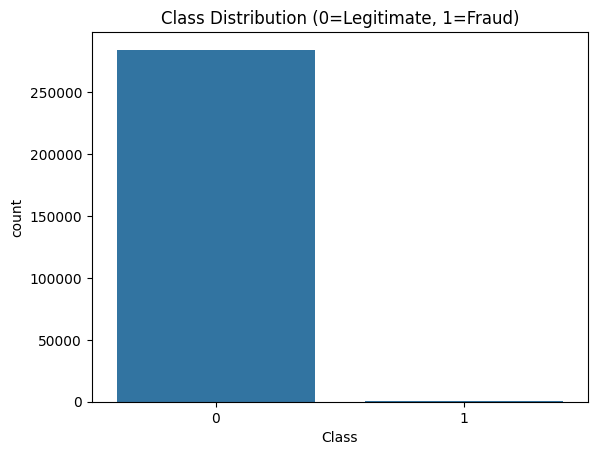

In [ ]:
# countplot - class distribution
sns.countplot(x='Class', data=df)
plt.title("Class Distribution (0=Legitimate, 1=Fraud)")
plt.show()

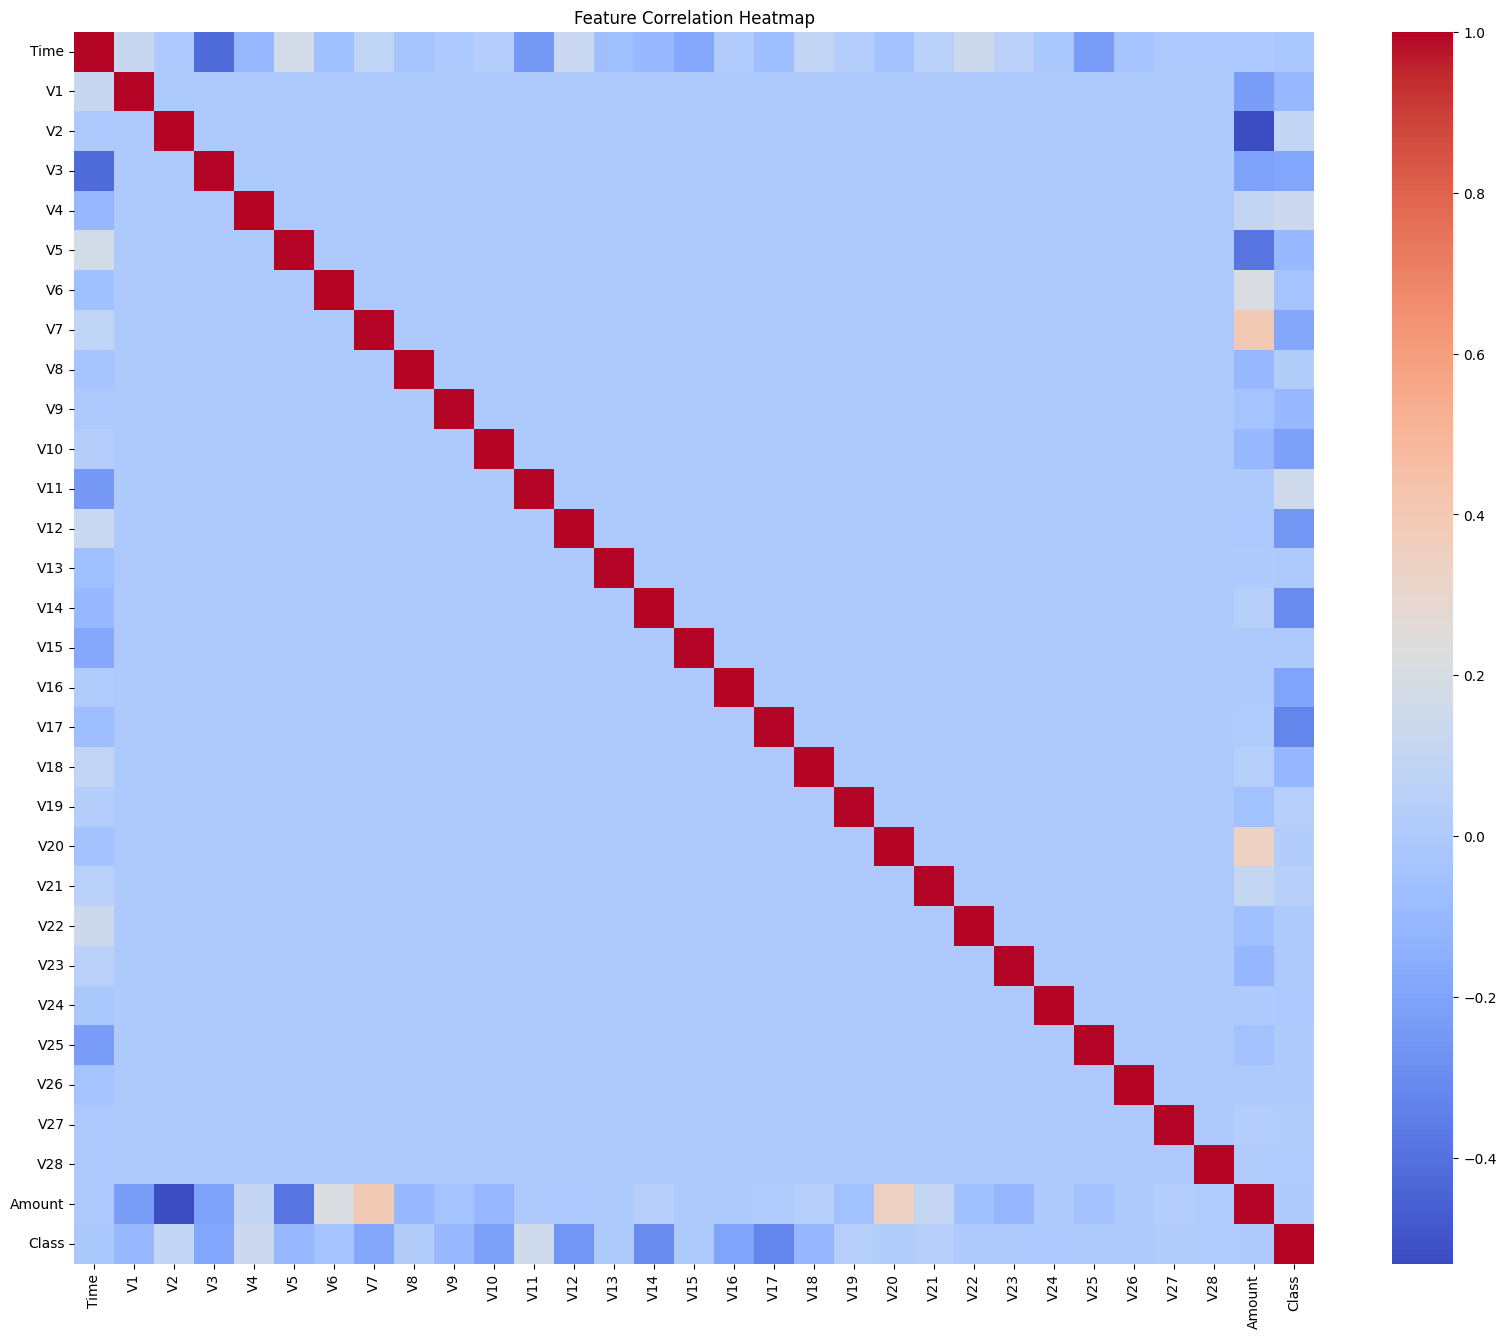

In [ ]:
# heatmap - correlations
plt.figure(figsize=(20, 16))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


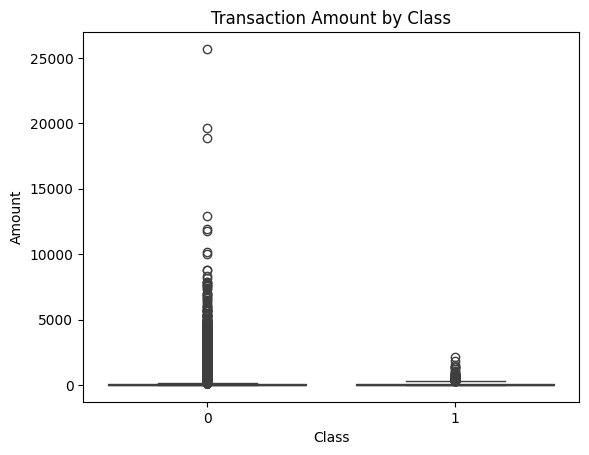

In [ ]:
# boxplot - amount by class
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Transaction Amount by Class")
plt.show()


# task 3
   DATA PREPROCESSING

In [ ]:

# separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 30)
y shape: (284807,)


In [ ]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])


Training samples: 227845
Test samples: 56962


In [ ]:
# feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# fit only on training data to prevent data leakage
X_test_scaled = scaler.transform(X_test)

print("StandardScaler applied successfully!")

# check class imbalance
print("Before SMOTE:")
print(y_train.value_counts())



StandardScaler applied successfully!
Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64



After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


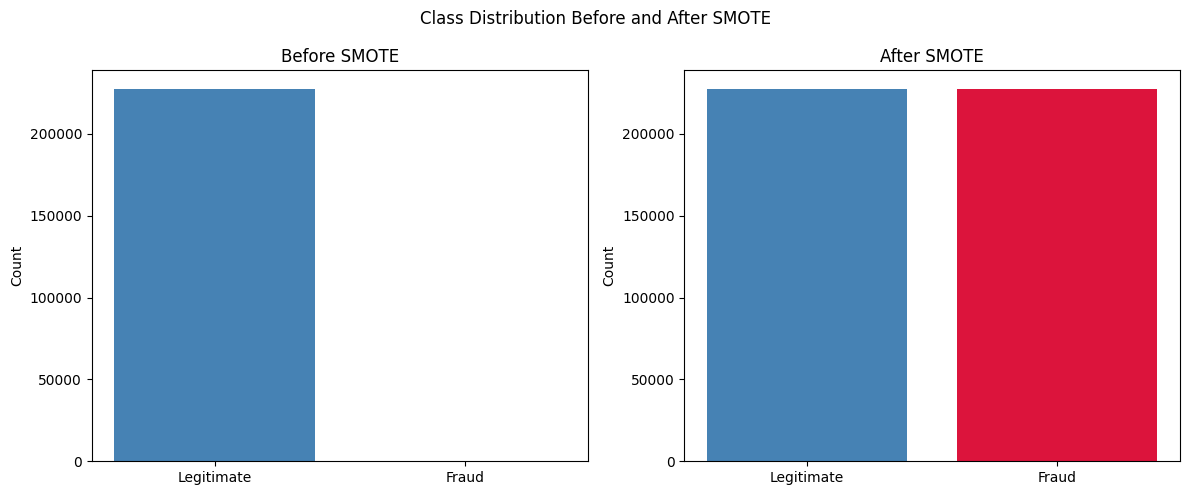

In [ ]:
# apply SMOTE to handle imbalance
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled, y_train
)

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# visualise before and after SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Legitimate', 'Fraud'],
            [y_train.value_counts()[0], y_train.value_counts()[1]],
            color=['steelblue', 'crimson'])
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')

after_counts = pd.Series(y_train_smote).value_counts()
axes[1].bar(['Legitimate', 'Fraud'],
            [after_counts[0], after_counts[1]],
            color=['steelblue', 'crimson'])
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')

plt.suptitle('Class Distribution Before and After SMOTE')
plt.tight_layout()
plt.show()

#task 4 model selection and training

# Model 1: Logistic Regression

In [ ]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_smote, y_train_smote)

# cross validation
cv_scores_lr = cross_val_score(
    lr_model, X_train_smote, y_train_smote, cv=5, scoring='f1'
)
print("Logistic Regression CV F1 Scores:", cv_scores_lr)
print("CV Mean:", round(cv_scores_lr.mean(), 4))

y_pred_lr = lr_model.predict(X_test_scaled)
print("\nTest Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr,
                             target_names=['Legitimate', 'Fraud']))

Logistic Regression CV F1 Scores: [0.9518964  0.95251669 0.95149099 0.95004443 0.95064146]
CV Mean: 0.9513

Test Accuracy: 0.9741055440469084

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



# hyperparameter tuning

In [50]:

from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10]}  # test different regularisation values
grid = GridSearchCV(
    LogisticRegression(max_iter=1000),  # model to tune
    param_grid,                          # parameters to search
    cv=3,                                # 3-fold cross validation
    scoring='f1'                         # optimise for F1 score
)
grid.fit(X_train_smote, y_train_smote)  # fit on SMOTE training data

print("Best Parameters:", grid.best_params_)   # best C value found
print("Best F1 Score:", round(grid.best_score_, 4))  # best F1 score

Best Parameters: {'C': 10}
Best F1 Score: 0.9514


# Model 2: Random Forest

In [42]:

rf_model = RandomForestClassifier(n_estimators=10, random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

cv_scores_rf = cross_val_score(
    rf_model, X_train_smote, y_train_smote, cv=5, scoring='f1'
)
print("Random Forest CV F1 Scores:", cv_scores_rf)
print("CV Mean:", round(cv_scores_rf.mean(), 4))

y_pred_rf = rf_model.predict(X_test_scaled)
print("\nTest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
                             target_names=['Legitimate', 'Fraud']))

Random Forest CV F1 Scores: [0.99992307 0.9998901  0.99974726 0.99992307 0.99989009]
CV Mean: 0.9999

Test Accuracy: 0.999420666409185

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.85      0.81      0.83        98

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962



# Model 3: XGBoost


In [37]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train_smote, y_train_smote)

cv_scores_xgb = cross_val_score(
    xgb_model, X_train_smote, y_train_smote, cv=5, scoring='f1'
)
print("XGBoost CV F1 Scores:", cv_scores_xgb)
print("CV Mean:", round(cv_scores_xgb.mean(), 4))

y_pred_xgb = xgb_model.predict(X_test_scaled)
print("\nTest Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
                             target_names=['Legitimate', 'Fraud']))

XGBoost CV F1 Scores: [0.99797949 0.998067   0.99816594 0.99825323 0.99778076]
CV Mean: 0.998

Test Accuracy: 0.9972437765527896

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56864
       Fraud       0.37      0.87      0.52        98

    accuracy                           1.00     56962
   macro avg       0.69      0.93      0.76     56962
weighted avg       1.00      1.00      1.00     56962



# cross validation comparison

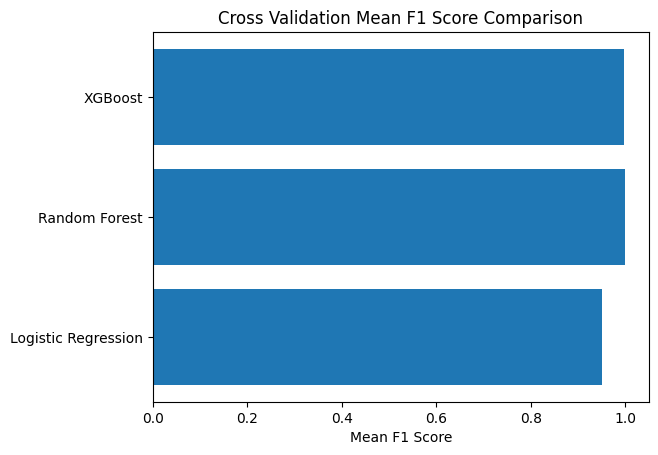

In [43]:
plt.figure()
plt.barh(
    ['Logistic Regression', 'Random Forest', 'XGBoost'],
    [cv_scores_lr.mean(), cv_scores_rf.mean(), cv_scores_xgb.mean()]
)
plt.xlabel('Mean F1 Score')
plt.title('Cross Validation Mean F1 Score Comparison')
plt.show()

# final model comparison table

In [49]:

model_names = ['Logistic Regression', 'Random Forest', 'XGBoost']
predictions = [y_pred_lr, y_pred_rf, y_pred_xgb]

results = []
for name, pred in zip(model_names, predictions):
    report = classification_report(y_test, pred, output_dict=True)
    results.append({
        'Model': name,
        'Test Accuracy': round(accuracy_score(y_test, pred), 4),
        'Precision (Fraud)': round(report['1']['precision'], 4),
        'Recall (Fraud)': round(report['1']['recall'], 4),
        'F1 (Fraud)': round(report['1']['f1-score'], 4),
    })

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by='F1 (Fraud)', ascending=False)
print("\n====================================")
print("FINAL MODEL COMPARISON")
print(df_results)


FINAL MODEL COMPARISON
                 Model  Test Accuracy  Precision (Fraud)  Recall (Fraud)  \
1        Random Forest         0.9994             0.8495          0.8061   
2              XGBoost         0.9972             0.3712          0.8673   
0  Logistic Regression         0.9741             0.0578          0.9184   

   F1 (Fraud)  
1      0.8272  
2      0.5199  
0      0.1088  


# TASK 5 - MODEL EVALUATION AND VISUALISATION

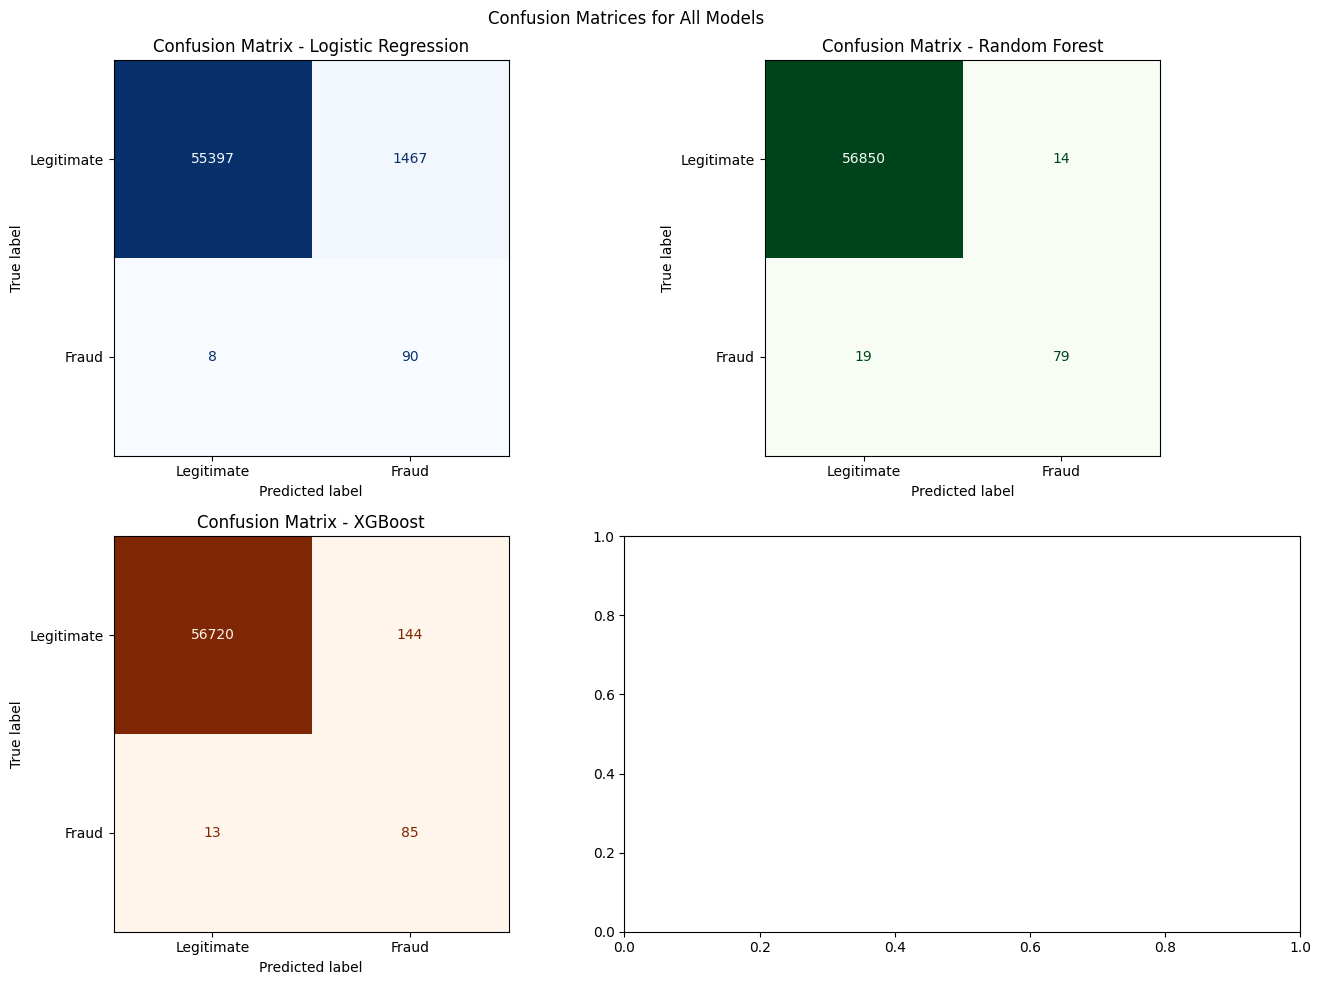

In [56]:

# confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = ['Blues', 'Greens', 'Oranges', 'Purples']

for ax, name, pred, color in zip(axes.flat, model_names,predictions, colors):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Legitimate', 'Fraud']
    )
    disp.plot(ax=ax, cmap=color, colorbar=False)
    ax.set_title(f'Confusion Matrix - {name}')

plt.suptitle('Confusion Matrices for All Models')
plt.tight_layout()
plt.show()

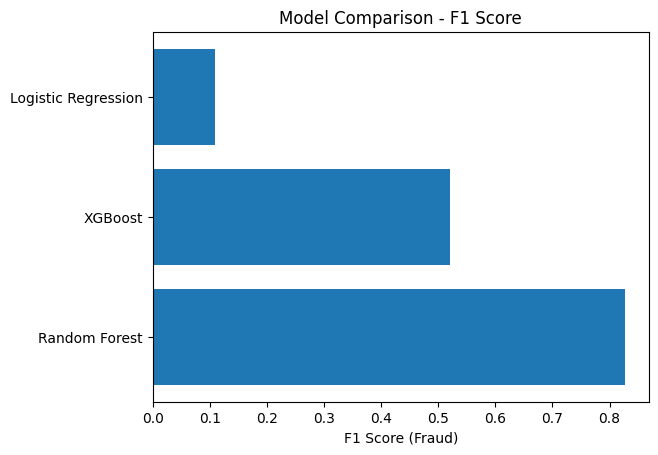

In [57]:
# model comparison bar chart - F1 Score
plt.figure()
plt.barh(df_results['Model'], df_results['F1 (Fraud)'])
plt.xlabel('F1 Score (Fraud)')
plt.title('Model Comparison - F1 Score')
plt.show()

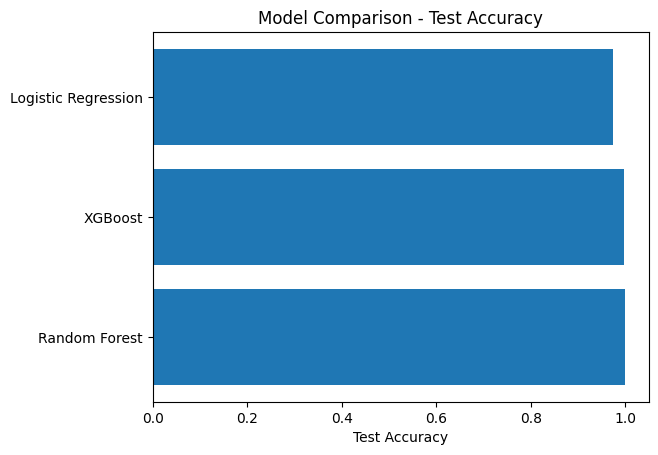

In [58]:
# model comparison bar chart - Test Accuracy
plt.figure()
plt.barh(df_results['Model'], df_results['Test Accuracy'])
plt.xlabel('Test Accuracy')
plt.title('Model Comparison - Test Accuracy')
plt.show()

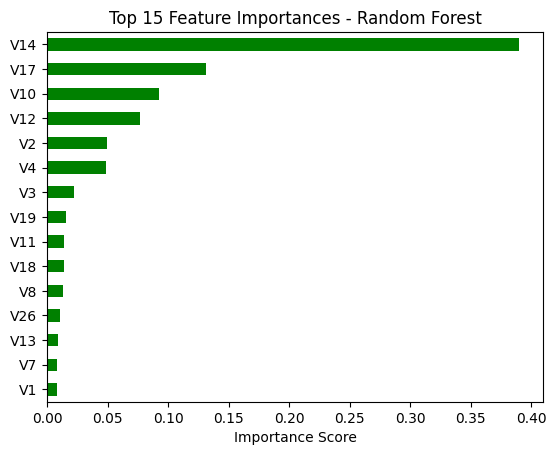

Top 5 features (Random Forest):
V14    0.390215
V17    0.131113
V10    0.092547
V12    0.077138
V2     0.049520
dtype: float64


In [59]:
# feature importance - random forest
feat_names = list(X.columns)
feat_imp_rf = pd.Series(
    rf_model.feature_importances_, index=feat_names
).sort_values(ascending=False)

feat_imp_rf.head(15).plot(kind='barh', color='green')
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

print("Top 5 features (Random Forest):")
print(feat_imp_rf.head(5))

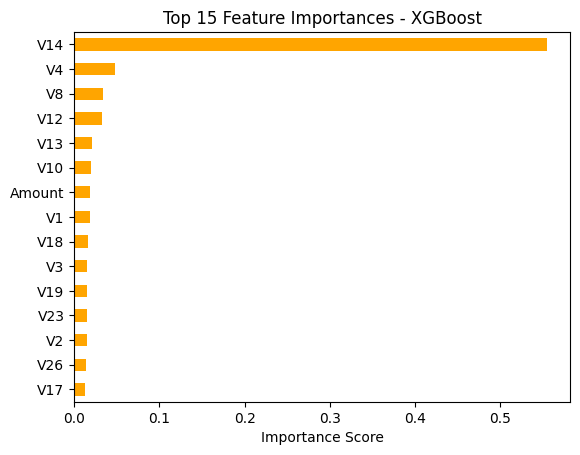

Top 5 features (XGBoost):
V14    0.554301
V4     0.047574
V8     0.033267
V12    0.032790
V13    0.020884
dtype: float32


In [60]:
# feature importance - xgboost
feat_imp_xgb = pd.Series(
    xgb_model.feature_importances_, index=feat_names
).sort_values(ascending=False)

feat_imp_xgb.head(15).plot(kind='barh', color='orange')
plt.title('Top 15 Feature Importances - XGBoost')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

print("Top 5 features (XGBoost):")
print(feat_imp_xgb.head(5))

In [61]:
# best model
best_model = df_results.iloc[0]
print("\n====================================")
print("BEST MODEL (based on F1 Score):")
print(best_model)
print("====================================")


BEST MODEL (based on F1 Score):
Model                Random Forest
Test Accuracy               0.9994
Precision (Fraud)           0.8495
Recall (Fraud)              0.8061
F1 (Fraud)                  0.8272
Name: 1, dtype: object
